In [1]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Cleaned Light Curve')

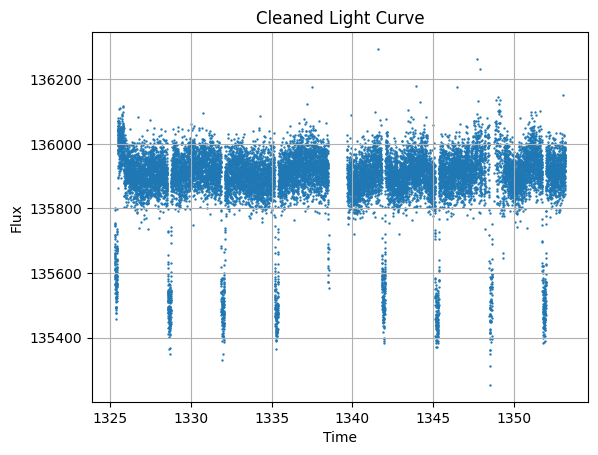

In [3]:

def clean_lc(file):
    """
    Cleans a light curve data file by removing rows with nan values and separating the time and flux data.

    Arguments:
    file (str): The file containing the light curve data.

    Returns:
    time (array): Array of time values
    flux (array): Array of flux values
    """
    
    data = np.genfromtxt(file)
    
    clear_data = data[~np.isnan(data).any(axis=1)] #remove the rows containing nan values 

    time, flux = clear_data[:,0], clear_data[:,1] #save the time and flux into seperate arrays, I got this from: https://stackoverflow.com/questions/11453141/how-to-remove-all-rows-in-a-numpy-ndarray-that-contain-non-numeric-values

    return time, flux

time, flux = clean_lc('tess_lc1.dat') 

plt.scatter(time, flux, s = 0.5) #plot the results 
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid(True)
plt.title('Cleaned Light Curve')

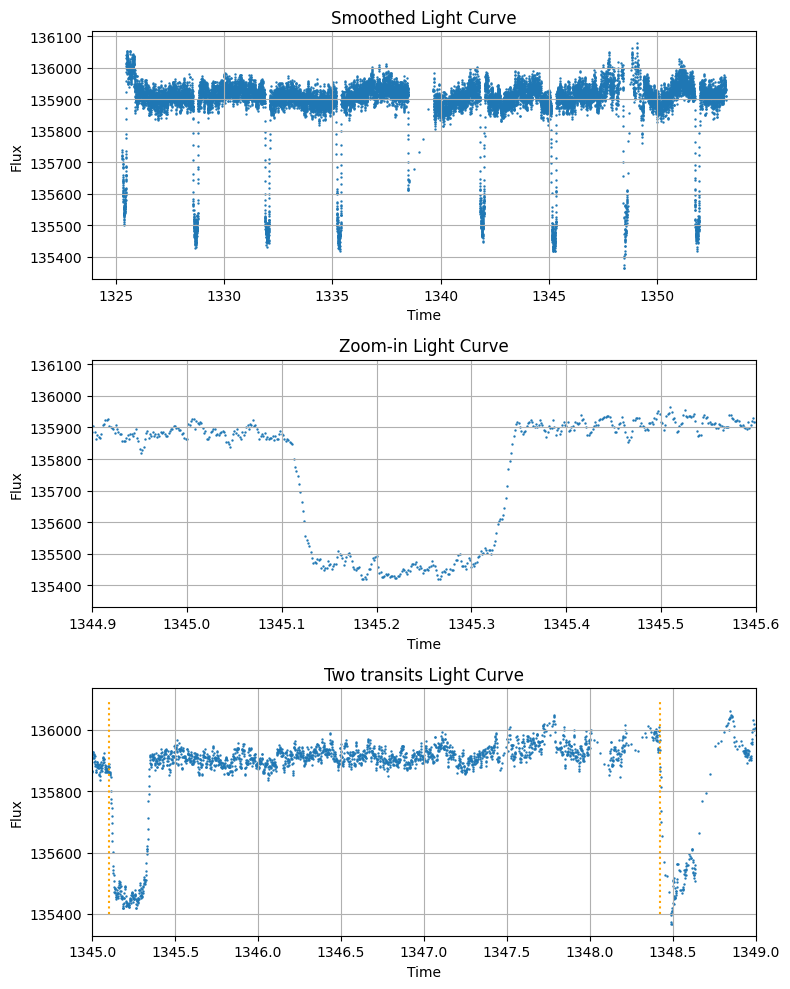

Orbital period of planet is approximately: Dt = 3.3200000000001637 days


In [4]:

def smoothed_curve(time, flux, window):
    """"
    Smooths a light curve using a sliding window and plots the results.

    Arguments:
    time (array): Array of time values
    flux (array): Array of flux values
    window (int): Size of the sliding window used for smoothing

    Returns:
    This function returns the plots of smoothed light curve and prints the orbital period.
    """

    smoothed_flux = np.convolve(flux, np.ones(window)/window, mode='valid') #found in https://www.projectpro.io/recipes/compute-averages-sliding-window-over-array
    smoothed_time = np.convolve(time, np.ones(window)/window, mode='valid')

    fig, ax = plt.subplots(3, 1, figsize=(8,10)) #subplots

    ax[0].scatter(smoothed_time, smoothed_flux, s=0.5)
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Flux')
    ax[0].grid(True)
    ax[0].set_title('Smoothed Light Curve')

    ax[1].scatter(smoothed_time, smoothed_flux, s=0.5)
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Flux')
    ax[1].set_xlim(1344.9,1345.6)
    ax[1].grid(True)
    ax[1].set_title('Zoom-in Light Curve')

    ax[2].scatter(smoothed_time, smoothed_flux, s=0.5)
    ax[2].set_xlabel('Time')
    ax[2].set_ylabel('Flux')
    ax[2].set_xlim(1345,1349)
    ax[2].grid(True)
    ax[2].set_title('Two transits Light Curve')
    t2 = 1348.42
    t1 = 1345.1
    ax[2].vlines(x=[t1, t2], ymin = 135400, ymax = 136100, color = 'orange', ls = ':', label = '') #select two lines to cut between the transits

    plt.tight_layout()
    plt.show()

    print("Orbital period of planet is approximately: Dt =", abs(t2-t1) ,"days")
    return
    

smoothed_curve(time, flux,5)


    


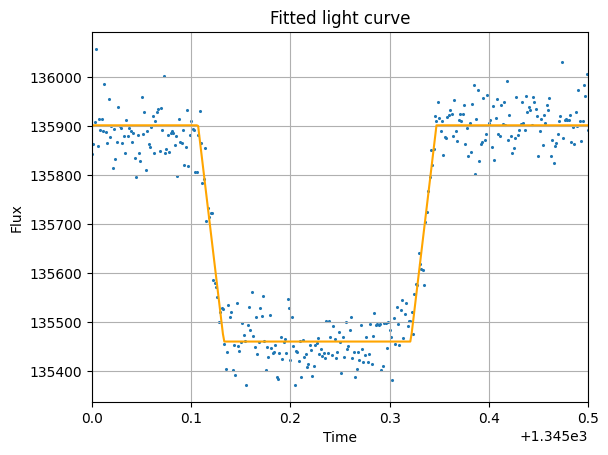

In [10]:

def flux_calculation(t, d, dt_total, dt_in, t_cent, f_star):
    """"
    Calculates the flux of a star during a planetary transit based on the time and other parameters.

    Parameters:
    t (array): Time array over which the flux is to be calculated.
    d (float): Depth of the transit
    dt_total (float): Total duration of the transit.
    dt_in (float): Duration of the ingress and egress phases.
    t_cent (float): Midpoint of the transit.
    f_star (float): Flux of the star outside of the transit.

    Returns:
    Array of flux values corresponding to the input time array t, with the transit applied.
    """"
   
    t = np.array(t)
    flux = np.full_like(t, f_star)
    
    # key times
    t_i = t_cent - dt_total / 2
    t_f = t_i + dt_total
    t_ingress = t_i + dt_in
    t_engress = t_f - dt_in  

    # masks for different phases
    ingress = (t >= t_i) & (t < t_ingress)
    full_eclipse = (t >= t_ingress) & (t < t_engress)
    egress = (t >= t_engress) & (t < t_f)

    # Apply the flux calculations to the appropriate phases
    flux[ingress] = f_star - d * (t[ingress] - t_i) / dt_in
    flux[full_eclipse] = f_star - d
    flux[egress] = f_star - d * (t_f - t[egress]) / dt_in

    return flux

#Initial parameters 
f_star = 135900.0  
d = 450  
t_cent = 1345.23  
delta_t_total = 0.25  
delta_t_in = 0.04  

popt, pcov = scipy.optimize.curve_fit(flux_calculation, time[13000:13500], flux[13000:13500], p0 = [d, delta_t_total, delta_t_in, t_cent, f_star])
fitted_flux = flux_calculation(time[13000:13500], *popt)
plt.scatter(time[13000:13500], flux[13000:13500], s = 1.5)
plt.plot(time[13000:13500], fitted_flux, color = 'orange')
plt.xlim(1345,1345.5)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title('Fitted light curve')
plt.grid(True)



Text(0.5, 1.0, 'Cleaned Light Curve')

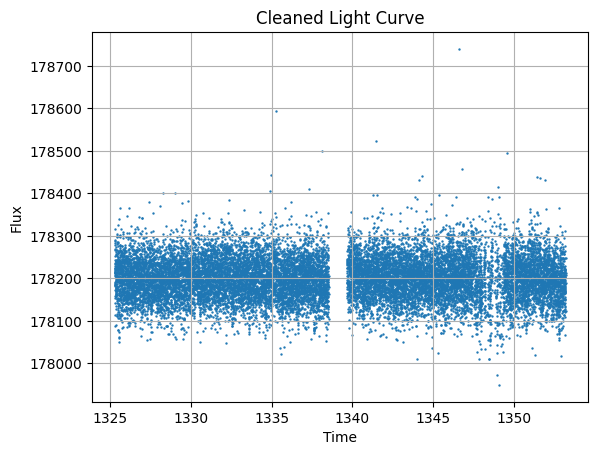

In [11]:
 
time2, flux2 = clean_lc('tess_lc2.dat') #use function to clean data 

#plot cleaned data 
plt.scatter(time2, flux2, s = 0.5) 
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid(True)
plt.title('Cleaned Light Curve')

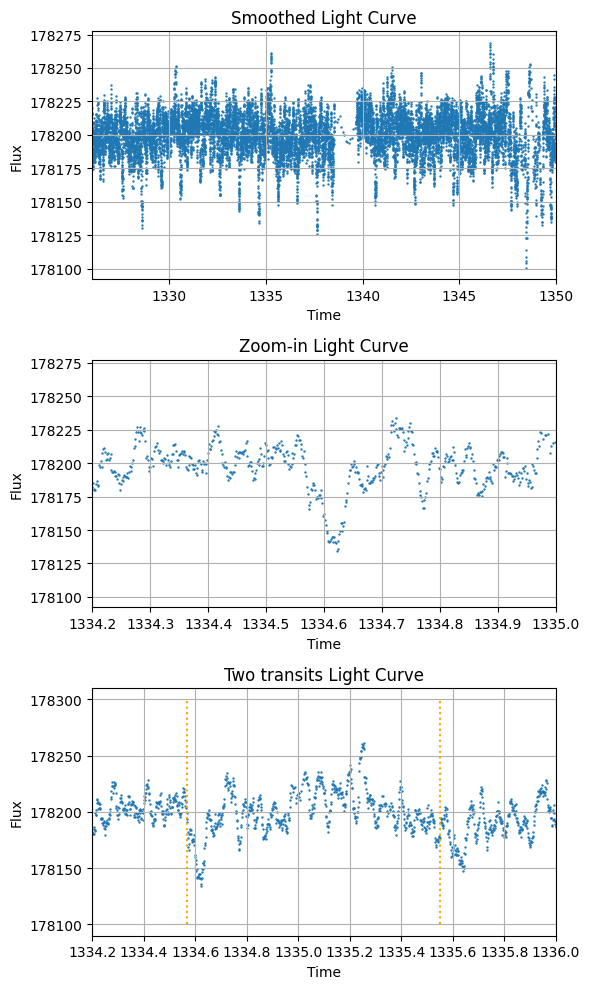

Orbital period of planet is approximately: Dt = 0.9800000000000182 days


In [20]:

def smoothed_curve2(time, flux, window):
    
    """"
    Smooths a light curve using a sliding window and plots the results.

    Arguments:
    time (array): Array of time values
    flux (array): Array of flux values
    window (int): Size of the sliding window used for smoothing

    Returns:
    This function returns the plots of smoothed light curve and prints the orbital period.
    """
    
    smoothed_flux = np.convolve(flux, np.ones(window)/window, mode='valid') #found in https://www.projectpro.io/recipes/compute-averages-sliding-window-over-array
    smoothed_time = np.convolve(time, np.ones(window)/window, mode='valid')


    fig, ax = plt.subplots(3, 1, figsize=(6, 10))

    ax[0].scatter(smoothed_time, smoothed_flux, s=0.5)
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Flux')
    ax[0].set_xlim(1326,1350)
    ax[0].grid(True)
    ax[0].set_title('Smoothed Light Curve')

    ax[1].scatter(smoothed_time, smoothed_flux, s=0.5)
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Flux')
    ax[1].set_xlim(1334.2,1335)
    ax[1].grid(True)
    ax[1].set_title('Zoom-in Light Curve')

    ax[2].scatter(smoothed_time, smoothed_flux, s=0.5)
    ax[2].set_xlabel('Time')
    ax[2].set_ylabel('Flux')
    ax[2].set_xlim(1334.2,1336)
    ax[2].grid(True)
    ax[2].set_title('Two transits Light Curve')
    t2 = 1334.57
    t1 = 1335.55
    ax[2].vlines(x=[t1, t2], ymin = 178100, ymax = 178300, color = 'orange', ls = ':', label = '') #select two lines to cut between the transits

    plt.tight_layout()
    plt.show()

    print("Orbital period of planet is approximately: Dt =", abs(t2-t1) ,"days")
    return smoothed_time, smoothed_flux
    

smoothed_t, smoothed_f = smoothed_curve2(time2, flux2, 15)


    


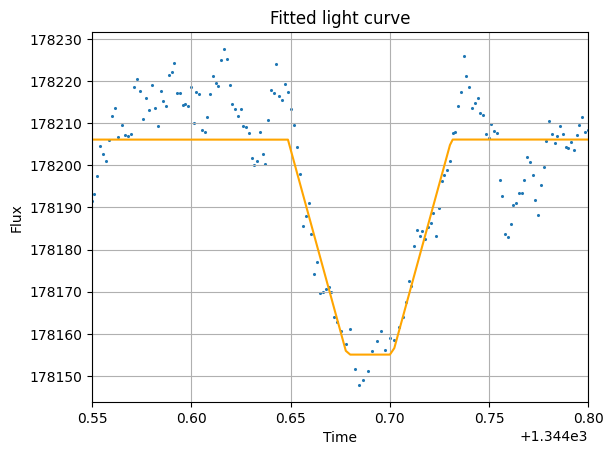

In [19]:
#parameters 
f_star = 178205.0   
d = 49
t_cent = 1344.69  
delta_t_total = 0.09  
delta_t_in = 0.03  

#use function to fit light curve of data2 
popt, pcov = scipy.optimize.curve_fit(flux_calculation, smoothed_t[12600:12900], smoothed_f[12600:12900], p0 = [d, delta_t_total, delta_t_in, t_cent, f_star])
fitted_flux2 = flux_calculation(smoothed_t[12600:12900], *popt)
plt.scatter(smoothed_t[12600:12900], smoothed_f[12600:12900], s = 1.5)
plt.plot(smoothed_t[12600:12900], fitted_flux2, color = 'orange')
plt.xlim(1344.55,1344.8)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title('Fitted light curve')
plt.grid(True)
